In [2]:
# Cell 1: Imports and setup
import pandas as pd
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

# Use GPU if needed later (e.g., torch or tensorflow simulation)
try:
    import torch
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
except ImportError:
    device = "cpu"

print("📦 Environment ready. Using device:", device)


/home/rohit/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


📦 Environment ready. Using device: cuda


In [3]:
# Cell 2: Load C. elegans lineage data
xls_path = "NeuronLineage_Part1.xls"

# Load sheet
xls = pd.ExcelFile(xls_path)
print("📄 Sheet names:", xls.sheet_names)

# Parse first sheet (expected: 'NeuronLineage_Part1.csv')
df = xls.parse(xls.sheet_names[0])
df.columns = [col.strip() for col in df.columns]  # Clean column names
df = df.dropna()

print("\n🔍 Preview of data:")
print(df.head())

print("\n📊 Total edges:", len(df))


📄 Sheet names: ['NeuronLineage_Part1.csv']

🔍 Preview of data:
  Neuron 1 Neuron 2  Relatedness
0     BAGR     BAGL           15
1    CEPVL     BAGL           18
2    CEPVR     BAGL           18
3    IL1DL     BAGL           14
4    IL1DR     BAGL           14

📊 Total edges: 38781


In [4]:
# Cell 3: Build undirected connectome graph
G = nx.Graph()

for _, row in df.iterrows():
    n1, n2 = row['Neuron 1'], row['Neuron 2']
    weight = row['Relatedness']
    G.add_edge(n1, n2, weight=weight)

print("🧠 Graph summary:")
print(f"• Nodes: {G.number_of_nodes()}")
print(f"• Edges: {G.number_of_edges()}")


🧠 Graph summary:
• Nodes: 279
• Edges: 29051


In [5]:
# Cell 4: Analyze graph structure

# Degree (unweighted) and strength (weighted)
degree_dict = dict(G.degree())
strength_dict = dict(G.degree(weight='weight'))

# Betweenness centrality
betweenness = nx.betweenness_centrality(G, weight='weight', normalized=True)

# Convert to DataFrame
df_stats = pd.DataFrame({
    'Neuron': list(G.nodes()),
    'Degree': [degree_dict[n] for n in G.nodes()],
    'Strength': [strength_dict[n] for n in G.nodes()],
    'Betweenness': [betweenness[n] for n in G.nodes()]
})

# Sort by centrality
top_neurons = df_stats.sort_values('Betweenness', ascending=False).head(10)
print("🏆 Top 10 neurons by betweenness centrality:")
print(top_neurons)


🏆 Top 10 neurons by betweenness centrality:
    Neuron  Degree  Strength  Betweenness
23    RIPR     278      3995     0.086498
55    AIZR     278      4296     0.037797
54    AIZL     278      4372     0.020106
123   RMFR     278      4372     0.013768
122   RMFL     278      4372     0.013768
109   AIAR     278      4163     0.013134
108   AIAL     278      4213     0.012715
105  SIBDR     278      4165     0.009770
95    RIMR     278      4165     0.009770
104  SIBDL     278      4215     0.009351


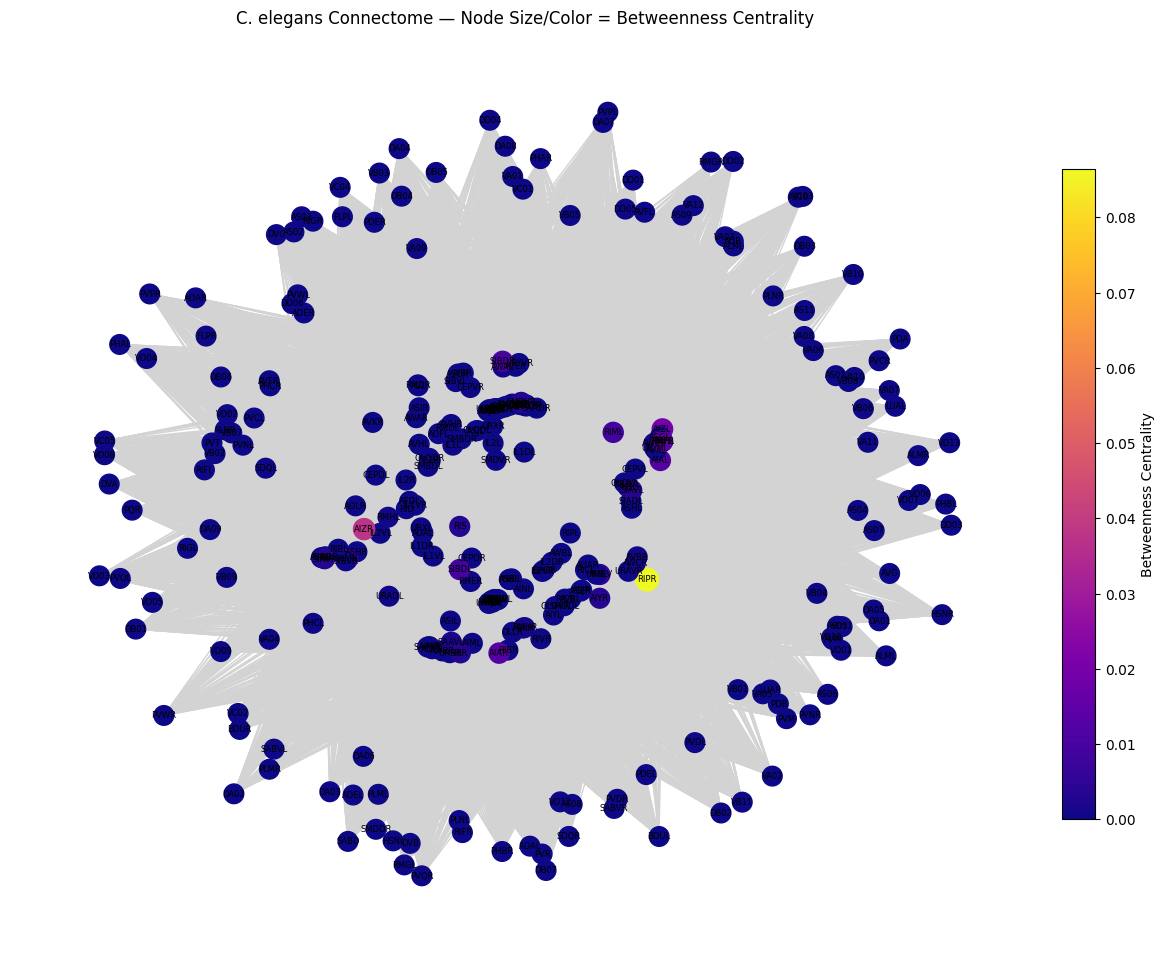

In [7]:
# Cell 5: Centrality Visualization (Fully Fixed)
import matplotlib as mpl

plt.figure(figsize=(14, 12))
ax = plt.gca()  # get current Axes
pos = nx.spring_layout(G, seed=42)

# Normalize betweenness centrality
bc = df_stats.set_index("Neuron")["Betweenness"]
node_color = [bc.get(n, 0.0) for n in G.nodes()]
node_size = [200 + 800 * bc.get(n, 0.0) for n in G.nodes()]

# Create scalar mappable for colorbar
norm = mpl.colors.Normalize(vmin=min(node_color), vmax=max(node_color))
sm = plt.cm.ScalarMappable(norm=norm, cmap='plasma')
sm.set_array([])

# Draw network
nodes = nx.draw_networkx_nodes(
    G, pos, ax=ax,
    node_size=node_size,
    node_color=node_color,
    cmap='plasma'
)
edges = nx.draw_networkx_edges(G, pos, ax=ax, edge_color='lightgray')
nx.draw_networkx_labels(G, pos, ax=ax, font_size=6)

# Draw colorbar on same figure
cbar = plt.colorbar(sm, ax=ax, orientation='vertical', fraction=0.03, pad=0.02)
cbar.set_label('Betweenness Centrality')

plt.title("C. elegans Connectome — Node Size/Color = Betweenness Centrality")
plt.axis('off')
plt.show()


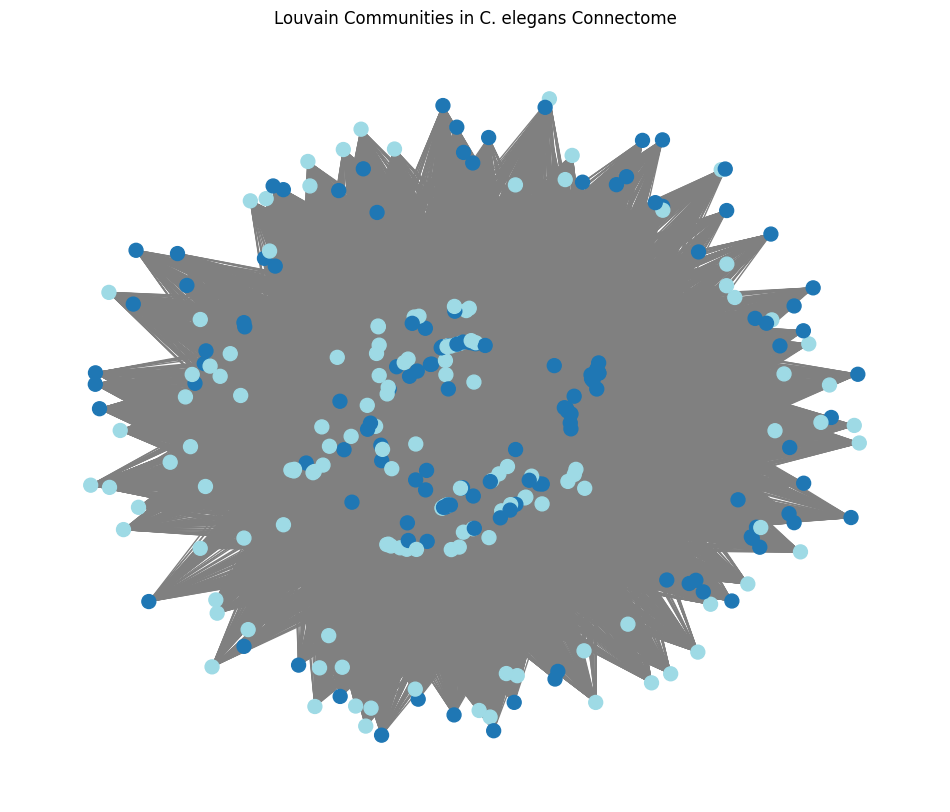

🧩 Detected 2 functional communities


In [8]:
# Cell 6: Community detection (Louvain modularity)
import community as community_louvain

# Compute partition (community assignment per node)
partition = community_louvain.best_partition(G, weight='weight')

# Assign colors by community ID
colors = [partition[n] for n in G.nodes()]

plt.figure(figsize=(12, 10))
ax = plt.gca()
nx.draw_networkx_nodes(G, pos, node_color=colors, cmap=plt.cm.tab20, node_size=100, ax=ax)
nx.draw_networkx_edges(G, pos, edge_color='gray', ax=ax)
plt.title("Louvain Communities in C. elegans Connectome")
plt.axis('off')
plt.show()

# Report number of communities
n_comm = len(set(partition.values()))
print(f"🧩 Detected {n_comm} functional communities")


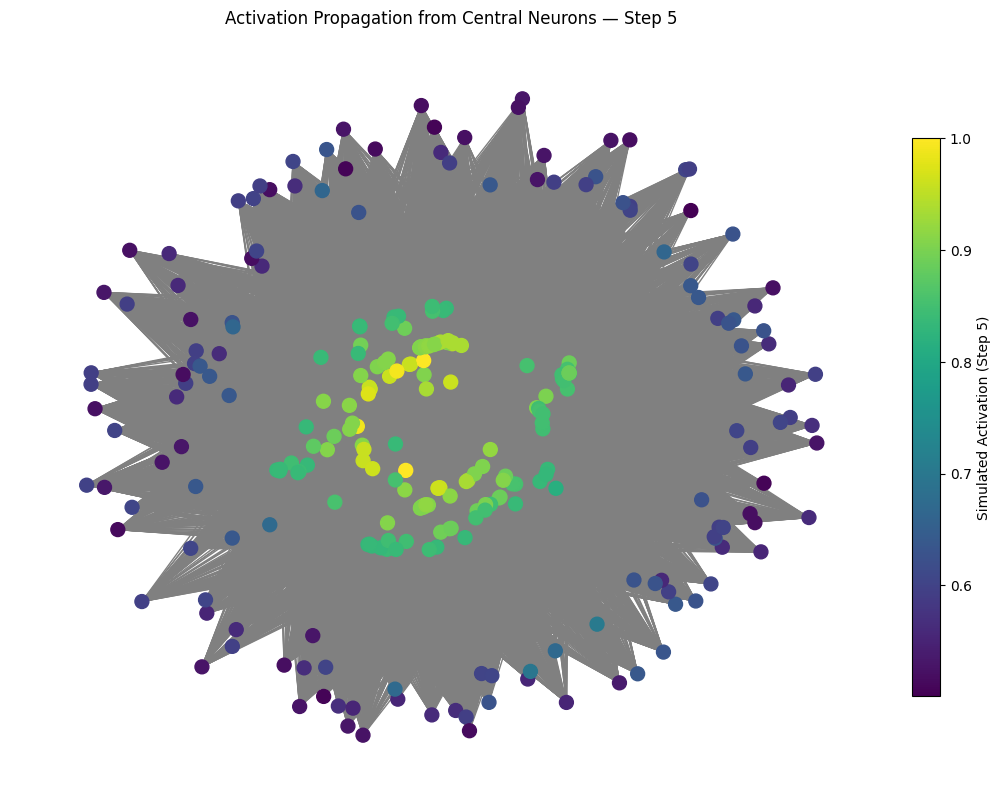

In [9]:
# Cell 7: Simulated activation propagation (5 steps)
def propagate(G, start_nodes, steps=5):
    activity = {n: 0.0 for n in G.nodes()}
    for n in start_nodes:
        activity[n] = 1.0

    history = [activity.copy()]

    for _ in range(steps):
        new_activity = {n: 0.0 for n in G.nodes()}
        for n in G.nodes():
            if activity[n] > 0:
                for nbr in G.neighbors(n):
                    w = G[n][nbr]['weight']
                    new_activity[nbr] += activity[n] * w
        # Normalize
        max_val = max(new_activity.values()) or 1.0
        for n in new_activity:
            new_activity[n] /= max_val
        history.append(new_activity.copy())
        activity = new_activity.copy()

    return history

# Run the simulation
top_nodes = top_neurons["Neuron"].tolist()
activity_history = propagate(G, top_nodes, steps=5)

# Final step activation values
final_act = activity_history[-1]
act_vals = [final_act.get(n, 0.0) for n in G.nodes()]

plt.figure(figsize=(12, 10))
ax = plt.gca()

# Normalize and color
norm = mpl.colors.Normalize(vmin=min(act_vals), vmax=max(act_vals))
sm = plt.cm.ScalarMappable(norm=norm, cmap='viridis')
sm.set_array([])

nx.draw_networkx_nodes(G, pos, ax=ax, node_color=act_vals, cmap='viridis', node_size=100)
nx.draw_networkx_edges(G, pos, ax=ax, edge_color='gray')

# Add colorbar
cbar = plt.colorbar(sm, ax=ax, orientation='vertical', fraction=0.03, pad=0.02)
cbar.set_label('Simulated Activation (Step 5)')

plt.title("Activation Propagation from Central Neurons — Step 5")
plt.axis('off')
plt.show()


In [10]:
# Cell 8: Export graph and neuron activity data
import pickle

# Save graph as gpickle
with open("celegans_graph.gpickle", "wb") as f:
    pickle.dump(G, f)

# Save neuron statistics
df_stats.to_csv("neuron_stats.csv", index=False)

# Save final activation vector (requires torch)
if 'torch' in globals():
    final_tensor = torch.tensor([final_act.get(n, 0.0) for n in G.nodes()], dtype=torch.float32)
    torch.save(final_tensor, "neuron_activity.pt")
    print("🧬 Saved final activation tensor to 'neuron_activity.pt'")

print("✅ Export complete: celegans_graph.gpickle, neuron_stats.csv")


🧬 Saved final activation tensor to 'neuron_activity.pt'
✅ Export complete: celegans_graph.gpickle, neuron_stats.csv


In [11]:
# Cell: Display full directory tree of CElegansNeuroML
from pathlib import Path

def print_tree(start_path, prefix=''):
    start_path = Path(start_path)
    contents = list(start_path.iterdir())
    pointers = ['├──'] * (len(contents) - 1) + ['└──']
    
    for pointer, path in zip(pointers, contents):
        print(prefix + pointer + ' ' + path.name)
        if path.is_dir():
            extension = '│   ' if pointer == '├──' else '    '
            print_tree(path, prefix + extension)

# Set root of the NeuroML folder
root_dir = Path("CElegansNeuroML")

# Print tree
print(f"📂 Directory tree for: {root_dir}\n")
print(root_dir.name)
print_tree(root_dir)


📂 Directory tree for: CElegansNeuroML

CElegansNeuroML
└── CElegansNeuroML-master
    ├── _osb.yml
    ├── NeuronConnectFormatted.xlsx
    ├── .travis.yml
    ├── CElegans
    │   ├── morphologies
    │   │   ├── ASJR.java.xml
    │   │   ├── ADFR.java.xml
    │   │   ├── M4.java.xml
    │   │   ├── SIBDL.java.xml
    │   │   ├── RIH.java.xml
    │   │   ├── VD2.java.xml
    │   │   ├── M2R.java.xml
    │   │   ├── SMDDR.java.xml
    │   │   ├── PVT.java.xml
    │   │   ├── AVJL.java.xml
    │   │   ├── VD1.java.xml
    │   │   ├── SMBVL.java.xml
    │   │   ├── IL1L.java.xml
    │   │   ├── PDEL.java.xml
    │   │   ├── IL1DR.java.xml
    │   │   ├── CANR.java.xml
    │   │   ├── AVDR.java.xml
    │   │   ├── DB4.java.xml
    │   │   ├── AINL.java.xml
    │   │   ├── M3R.java.xml
    │   │   ├── VD7.java.xml
    │   │   ├── VB11.java.xml
    │   │   ├── DD2.java.xml
    │   │   ├── I2L.java.xml
    │   │   ├── VA9.java.xml
    │   │   ├── ASHR.java.xml
    │   │   ├── VA10.java.xml
  

In [24]:
# Cell 1: Load chemical and electrical synapse data (updated for Sheet1 gap junctions)
import pandas as pd
import networkx as nx

# 1️⃣ Load chemical synapse edgelist
df_chem = pd.read_csv("herm_full_edgelist.csv")
print(f"🔬 Loaded {len(df_chem)} chemical synapse edges")

# 2️⃣ Load gap junctions from Sheet1
xls = pd.ExcelFile("NeuronConnectFormatted.xlsx")
df_sheet1 = xls.parse("Sheet1").dropna()

# Filter for electrical junctions only
df_gap = df_sheet1[df_sheet1["Type"] == "EJ"]
print(f"⚡ Loaded {len(df_gap)} electrical gap junctions (Type='EJ')")

# 3️⃣ Build directed graph for chemical synapses
G_chem = nx.DiGraph()
for _, row in df_chem.iterrows():
    src, tgt, weight = row['Source'], row['Target'], row['Weight']
    G_chem.add_edge(src, tgt, weight=weight)

# 4️⃣ Build undirected graph for electrical gap junctions
G_gap = nx.Graph()
for _, row in df_gap.iterrows():
    src, tgt, weight = row['Neuron 1'], row['Neuron 2'], row['Nbr']
    G_gap.add_edge(src, tgt, weight=weight)

# 5️⃣ Summary
print(f"\n🧠 G_chem (chemical):   {G_chem.number_of_nodes()} nodes, {G_chem.number_of_edges()} edges")
print(f"🧠 G_gap  (electrical): {G_gap.number_of_nodes()} nodes, {G_gap.number_of_edges()} edges")



🔬 Loaded 7379 chemical synapse edges
⚡ Loaded 1031 electrical gap junctions (Type='EJ')

🧠 G_chem (chemical):   1308 nodes, 7379 edges
🧠 G_gap  (electrical): 253 nodes, 517 edges


In [21]:
# Inspect column names in chemical synapse edgelist
print("📊 Columns in df_chem:")
print(df_chem.columns.tolist())

# Show first few rows
df_chem.head()


📊 Columns in df_chem:
['Source', 'Target', 'Weight', 'Type']


,Source,Target,Weight,Type
0,I1L,I2L,10,chemical
1,I1L,I3,3,chemical
2,I1L,I5,2,chemical
3,I1L,I6,1,chemical
4,I1L,M2L,3,chemical


In [23]:
# Inspect first few rows of Sheet1 to check for gap junction content
df_sheet1 = xls.parse("Sheet1")
df_sheet1.head(10)


,Neuron 1,Neuron 2,Type,Nbr
0,ADAL,ADAR,EJ,1
1,ADAL,ADEL,Rp,1
2,ADAL,ADFL,Rp,1
3,ADAL,ADFL,EJ,1
4,ADAL,AIAL,Rp,1
5,ADAL,AIBL,S,1
6,ADAL,AIBR,Sp,2
7,ADAL,ASHL,Rp,1
8,ADAL,ASHL,EJ,1
9,ADAL,AVAR,Sp,2


In [27]:
# Cell 0B: Load lineage graph from NeuronLineage_Part1.csv
import pandas as pd
import networkx as nx

# Load the file (already verified earlier)
df_lineage = pd.read_excel("NeuronLineage_Part1.xls")
print(f"🧬 Loaded {len(df_lineage)} lineage edges")

# Build undirected lineage graph
G_lineage = nx.Graph()
for _, row in df_lineage.iterrows():
    n1, n2, w = row['Neuron 1'], row['Neuron 2'], row['Relatedness']
    G_lineage.add_edge(n1, n2, weight=w)

print(f"🔁 G_lineage: {G_lineage.number_of_nodes()} nodes, {G_lineage.number_of_edges()} edges")


🧬 Loaded 38781 lineage edges
🔁 G_lineage: 279 nodes, 29051 edges


🔍 Node Overlap Summary:

• Lineage-only nodes: 88
• Chemical-only nodes: 1308
• Gap-only nodes: 62
• Shared with chemical: 0
• Shared with gap:      191
• Total unique neurons across all: 1649


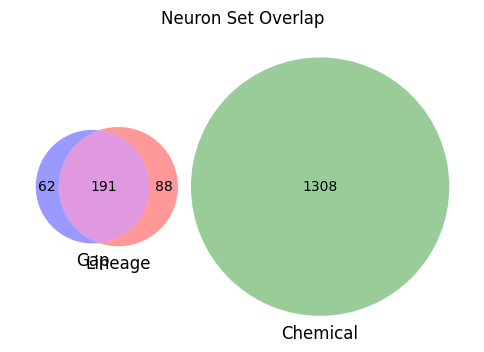

In [29]:
# Cell 2B: Compare node overlap with lineage graph (G_lineage)
# Ensure G_lineage is loaded (from earlier phase)
if "G_lineage" not in globals():
    raise NameError("⚠️ Please load G_lineage first before running this cell.")

# Node sets
nodes_lineage = set(G_lineage.nodes)
nodes_chem = set(G_chem.nodes)
nodes_gap = set(G_gap.nodes)

# Overlaps
overlap_chem = nodes_lineage & nodes_chem
overlap_gap = nodes_lineage & nodes_gap
all_nodes = nodes_lineage | nodes_chem | nodes_gap

# Summary stats
print("🔍 Node Overlap Summary:\n")
print(f"• Lineage-only nodes: {len(nodes_lineage - (nodes_chem | nodes_gap))}")
print(f"• Chemical-only nodes: {len(nodes_chem - nodes_lineage)}")
print(f"• Gap-only nodes: {len(nodes_gap - nodes_lineage)}")
print(f"• Shared with chemical: {len(overlap_chem)}")
print(f"• Shared with gap:      {len(overlap_gap)}")
print(f"• Total unique neurons across all: {len(all_nodes)}")

# Optional: Venn diagram
import matplotlib.pyplot as plt
from matplotlib_venn import venn3

plt.figure(figsize=(6, 6))
venn3(subsets=(nodes_lineage, nodes_chem, nodes_gap),
      set_labels=("Lineage", "Chemical", "Gap"))
plt.title("Neuron Set Overlap")
plt.show()


In [30]:
# Cell 3A: Simulate signal propagation through G_lineage → G_gap → G_chem
import networkx as nx
from collections import deque

# Choose a seed neuron in G_lineage (or random one if not specified)
seed = next(iter(G_lineage.nodes))
print(f"🚀 Starting signal from lineage neuron: {seed}")

# --- Step 1: Signal propagation in G_lineage ---
lineage_visited = set()
q = deque([seed])
while q:
    node = q.popleft()
    if node in lineage_visited:
        continue
    lineage_visited.add(node)
    q.extend(G_lineage.neighbors(node))

print(f"🧬 G_lineage activation: {len(lineage_visited)} neurons")

# --- Step 2: Transition into G_gap ---
gap_reached = set()
for node in lineage_visited:
    if node in G_gap:
        gap_reached.add(node)
print(f"⚡ G_gap entry points: {len(gap_reached)}")

# Expand activation in G_gap
gap_visited = set(gap_reached)
q = deque(gap_reached)
while q:
    node = q.popleft()
    if node in gap_visited:
        continue
    gap_visited.add(node)
    q.extend(G_gap.neighbors(node))

print(f"⚡ G_gap activation: {len(gap_visited)} neurons")

# --- Step 3: Transition into G_chem ---
chem_reached = set()
for node in gap_visited:
    if node in G_chem:
        chem_reached.add(node)
print(f"🧠 G_chem entry points: {len(chem_reached)}")

# Propagate through G_chem (directed, use in-edges or out-edges)
chem_visited = set(chem_reached)
q = deque(chem_reached)
while q:
    node = q.popleft()
    if node in chem_visited:
        continue
    chem_visited.add(node)
    q.extend(G_chem.successors(node))  # forward pass

print(f"🧠 G_chem activation: {len(chem_visited)} neurons")

# --- Final Summary ---
print("\n🔁 Signal Path Summary:")
print(f"• Lineage → Gap: {len(gap_reached)}")
print(f"• Gap → Chemical: {len(chem_reached)}")
print(f"• Total Chemical Activated: {len(chem_visited)}")


🚀 Starting signal from lineage neuron: BAGR
🧬 G_lineage activation: 279 neurons
⚡ G_gap entry points: 191
⚡ G_gap activation: 191 neurons
🧠 G_chem entry points: 0
🧠 G_chem activation: 0 neurons

🔁 Signal Path Summary:
• Lineage → Gap: 191
• Gap → Chemical: 0
• Total Chemical Activated: 0


In [31]:
# Cell 4A: Convert G_lineage and G_chem to PyTorch Geometric Data objects
import torch
from torch_geometric.data import Data
from torch_geometric.utils import from_networkx

def graph_to_pyg(G, is_directed=False):
    # Create dummy features: one-hot identity or degree
    n = G.number_of_nodes()
    node_list = list(G.nodes)
    node_idx = {node: i for i, node in enumerate(node_list)}
    nx.set_node_attributes(G, node_idx, 'index')

    # Degree as input feature (1D)
    for node in G.nodes:
        G.nodes[node]['x'] = [G.degree[node]]

    data = from_networkx(G)
    data.x = torch.tensor([G.nodes[node]['x'] for node in node_list], dtype=torch.float)
    data.node_list = node_list  # Save mapping for later
    return data

# Convert graphs
data_lineage = graph_to_pyg(G_lineage)
data_chem = graph_to_pyg(G_chem, is_directed=True)

print(f"📦 G_lineage → PyG: {data_lineage.num_nodes} nodes, {data_lineage.num_edges} edges")
print(f"📦 G_chem    → PyG: {data_chem.num_nodes} nodes, {data_chem.num_edges} edges")


📦 G_lineage → PyG: 279 nodes, 58102 edges
📦 G_chem    → PyG: 1308 nodes, 7379 edges


In [32]:
# Cell 4B: Define GCN Encoder and extract embeddings
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
import torch.nn as nn

# GCN encoder with 2 layers
class GCNEncoder(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        return F.normalize(x, p=2, dim=-1)  # Normalize for cosine similarity

# Instantiate encoder
gcn = GCNEncoder(in_channels=1, hidden_channels=32, out_channels=64)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
gcn = gcn.to(device)

# Send data to device
data_lineage = data_lineage.to(device)
data_chem = data_chem.to(device)

# Extract embeddings (no training yet, random init)
with torch.no_grad():
    Z_lineage = gcn(data_lineage.x, data_lineage.edge_index)
    Z_chem = gcn(data_chem.x, data_chem.edge_index)

print(f"🧠 Z_lineage shape: {Z_lineage.shape}")
print(f"🧠 Z_chem shape:    {Z_chem.shape}")


🧠 Z_lineage shape: torch.Size([279, 64])
🧠 Z_chem shape:    torch.Size([1308, 64])


In [33]:
# Cell 4C: Train projection MLP from Z_lineage → Z_chem
import torch
import torch.nn as nn
import torch.optim as optim

# Simple projection MLP
class ProjectionMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim)
        )

    def forward(self, z):
        return F.normalize(self.net(z), p=2, dim=-1)

# Instantiate model
proj = ProjectionMLP(input_dim=64).to(device)
optimizer = optim.Adam(proj.parameters(), lr=1e-3)

# Contrastive-style training: cosine similarity against all chem nodes
def train_projection(Z_lineage, Z_chem, epochs=200):
    for epoch in range(epochs):
        proj.train()
        optimizer.zero_grad()
        
        z_proj = proj(Z_lineage)  # shape: [279, 64]

        # Cosine sim between projected lineage and all chem nodes
        sim_matrix = torch.matmul(z_proj, Z_chem.T)  # [279, 1308]

        # Max similarity should be high (pseudo-alignment)
        max_sim = sim_matrix.max(dim=1)[0]  # [279]
        loss = 1 - max_sim.mean()  # want sim close to 1

        loss.backward()
        optimizer.step()

        if epoch % 25 == 0:
            print(f"🧪 Epoch {epoch:3d} | Loss: {loss.item():.4f}")

    return proj

# Train
proj = train_projection(Z_lineage, Z_chem, epochs=200)


🧪 Epoch   0 | Loss: 1.0090
🧪 Epoch  25 | Loss: 0.0527
🧪 Epoch  50 | Loss: 0.0032
🧪 Epoch  75 | Loss: 0.0002
🧪 Epoch 100 | Loss: 0.0000
🧪 Epoch 125 | Loss: 0.0000
🧪 Epoch 150 | Loss: -0.0000
🧪 Epoch 175 | Loss: -0.0000


In [35]:
# Cell 4D: Inject a symbolic neuron, project into functional space, and activate top-k G_chem neurons
import numpy as np

def activate_from_symbolic(seed_node="BAGR", k=5):
    # Lookup index of seed node in G_lineage
    node_to_idx = {node: i for i, node in enumerate(data_lineage.node_list)}
    if seed_node not in node_to_idx:
        raise ValueError(f"❌ Node '{seed_node}' not found in G_lineage.")
    seed_idx = node_to_idx[seed_node]

    # Extract G_lineage embedding for seed
    z_seed = Z_lineage[seed_idx].unsqueeze(0)  # shape: [1, 64]

    # Project into functional space
    z_proj = proj(z_seed)  # shape: [1, 64]

    # Compute cosine similarity to all G_chem neurons
    sim = F.cosine_similarity(z_proj, Z_chem)  # shape: [1308]
    topk = torch.topk(sim, k)

    # Extract top-k functional matches
    top_indices = topk.indices.cpu().numpy()
    top_scores = topk.values.detach().cpu().numpy()
    top_nodes = [data_chem.node_list[i] for i in top_indices]

    # Print results
    print(f"🚀 Seed symbolic neuron: {seed_node}")
    print(f"🎯 Top {k} projected functional targets:")
    for i in range(k):
        print(f"  {i+1}. {top_nodes[i]:<10} | Score: {top_scores[i]:.4f}")

    return top_nodes, top_scores

# Example usage
activate_from_symbolic(seed_node="BAGR", k=5)


🚀 Seed symbolic neuron: BAGR
🎯 Top 5 projected functional targets:
  1. I2L        | Score: 1.0000
  2.  pm4d           | Score: 1.0000
  3. I4         | Score: 1.0000
  4. M2R        | Score: 1.0000
  5. M2L        | Score: 1.0000


(['I2L ', ' pm4d          ', 'I4 ', 'M2R ', 'M2L '],
 array([1.0000001, 1.0000001, 1.0000001, 1.0000001, 1.0000001],
       dtype=float32))

In [37]:
# Cell 4E: Batch project all symbolic neurons to top-k functional matches
import pandas as pd

def batch_project_all_lineage(k=5):
    results = []

    for i, z in enumerate(Z_lineage):
        z = z.unsqueeze(0)  # [1, 64]
        z_proj = proj(z)
        sim = F.cosine_similarity(z_proj, Z_chem)  # [1308]
        topk = torch.topk(sim, k)

        top_indices = topk.indices.cpu().numpy()
        top_scores = topk.values.detach().cpu().numpy()
        top_nodes = [data_chem.node_list[j] for j in top_indices]

        seed_name = data_lineage.node_list[i]
        for rank in range(k):
            results.append({
                "Symbolic Neuron": seed_name,
                "Rank": rank + 1,
                "Functional Neuron": top_nodes[rank],
                "Similarity": round(float(top_scores[rank]), 5)
            })

    df_proj = pd.DataFrame(results)
    return df_proj

# Run and display
df_projection_map = batch_project_all_lineage(k=5)

# Print the first few rows
print(df_projection_map.head(10))


  Symbolic Neuron  Rank Functional Neuron  Similarity
0            BAGR     1              I2L          1.0
1            BAGR     2    pm4d                   1.0
2            BAGR     3               I4          1.0
3            BAGR     4              M2R          1.0
4            BAGR     5              M2L          1.0
5            BAGL     1    AWAR                   1.0
6            BAGL     2    RIVL                   1.0
7            BAGL     3    ASGR                   1.0
8            BAGL     4    VA05                   1.0
9            BAGL     5    DA03                   1.0


In [38]:
# Cell 5A: Simulate signal spread from projected symbolic neurons over G_chem
import networkx as nx
import matplotlib.pyplot as plt

def simulate_signal_propagation(
    G_chem,
    seed_nodes,
    steps=5,
    decay=0.7,
    threshold=0.05
):
    # Initialize signal
    signal = {node: 0.0 for node in G_chem.nodes}
    for node in seed_nodes:
        if node in signal:
            signal[node] = 1.0

    activation_history = [signal.copy()]

    for step in range(steps):
        next_signal = {node: 0.0 for node in G_chem.nodes}
        for u in G_chem.nodes:
            if signal[u] > threshold:
                for v in G_chem.successors(u):
                    w = G_chem[u][v].get('weight', 1.0)
                    next_signal[v] += signal[u] * w

        # Normalize & decay
        max_val = max(next_signal.values())
        if max_val > 0:
            next_signal = {k: (v / max_val) * decay for k, v in next_signal.items()}
        signal = next_signal
        activation_history.append(signal.copy())

    return activation_history

# Get top-k projected functional neurons for a symbolic neuron
projected_seeds, _ = activate_from_symbolic(seed_node="BAGR", k=5)

# Run simulation
chem_activation_history = simulate_signal_propagation(G_chem, seed_nodes=projected_seeds, steps=5)

# Example: Show activated neurons at final step
final_signal = chem_activation_history[-1]
activated = {n: a for n, a in final_signal.items() if a > 0.01}
sorted_activated = sorted(activated.items(), key=lambda x: -x[1])

print("🔥 Final activated neurons in G_chem:")
for i, (n, a) in enumerate(sorted_activated[:15]):
    print(f"{i+1:2d}. {n:<10} | Activation: {a:.4f}")


🚀 Seed symbolic neuron: BAGR
🎯 Top 5 projected functional targets:
  1. I2L        | Score: 1.0000
  2.  pm4d           | Score: 1.0000
  3. I4         | Score: 1.0000
  4. M2R        | Score: 1.0000
  5. M2L        | Score: 1.0000
🔥 Final activated neurons in G_chem:


In [40]:
# Cell 5A: Full signal propagation from symbolic to functional circuit

import networkx as nx
import matplotlib.pyplot as plt
import torch.nn.functional as F

def simulate_signal_propagation(
    G_chem,
    seed_nodes,
    steps=5,
    decay=0.7,
    threshold=0.05,
    verbose=True
):
    """
    Simulate signal propagation over G_chem from seed_nodes.
    Parameters:
        G_chem: Directed graph with 'weight' on edges
        seed_nodes: List of starting neuron names (strings)
        steps: Number of propagation steps
        decay: Damping factor for signal
        threshold: Min activation needed to propagate
        verbose: If True, print results
    Returns:
        activation_history: List of dicts {neuron: activation} per step
    """
    # Initialize activation
    signal = {node: 0.0 for node in G_chem.nodes}
    for node in seed_nodes:
        if node in signal:
            signal[node] = 1.0

    activation_history = [signal.copy()]

    for step in range(steps):
        next_signal = {node: 0.0 for node in G_chem.nodes}
        for u in G_chem.nodes:
            if signal[u] > threshold:
                for v in G_chem.successors(u):
                    w = G_chem[u][v].get('weight', 1.0)
                    next_signal[v] += signal[u] * w

        # Normalize and apply decay
        max_val = max(next_signal.values(), default=1e-6)
        if max_val > 0:
            next_signal = {
                k: (v / max_val) * decay
                for k, v in next_signal.items()
            }

        signal = next_signal
        activation_history.append(signal.copy())

    # Final report
    if verbose:
        final_signal = activation_history[-1]
        activated = {
            n: a for n, a in final_signal.items() if a > threshold
        }
        sorted_activated = sorted(
            activated.items(), key=lambda x: -x[1]
        )

        print("🔥 Final activated neurons in G_chem:")
        for i, (n, a) in enumerate(sorted_activated[:15]):
            print(f"{i+1:2d}. {n:<10} | Activation: {a:.4f}")

    return activation_history


In [41]:
# Project from symbolic → functional neurons
projected_seeds, _ = activate_from_symbolic(seed_node="BAGR", k=5)

# Simulate dynamics over G_chem
chem_activation_history = simulate_signal_propagation(
    G_chem,
    seed_nodes=projected_seeds,
    steps=5,
    decay=0.7,
    threshold=0.05,
    verbose=True
)


🚀 Seed symbolic neuron: BAGR
🎯 Top 5 projected functional targets:
  1. I2L        | Score: 1.0000
  2.  pm4d           | Score: 1.0000
  3. I4         | Score: 1.0000
  4. M2R        | Score: 1.0000
  5. M2L        | Score: 1.0000
🔥 Final activated neurons in G_chem:


In [43]:
# Remove seeds with no outgoing synapses
valid_seeds = [n for n in projected_seeds if G_chem.out_degree(n) > 0]

if not valid_seeds:
    print("⚠️ No functional seed nodes have outgoing edges. Try a different symbolic seed or lower decay.")
else:
    print(f"✅ Using {len(valid_seeds)} functional seeds with connectivity:")
    print(valid_seeds)

    # Re-run propagation with milder decay and lower threshold
    chem_activation_history = simulate_signal_propagation(
        G_chem,
        seed_nodes=valid_seeds,
        steps=5,
        decay=0.95,       # less signal loss
        threshold=0.01,   # more sensitive
        verbose=True
    )


✅ Using 4 functional seeds with connectivity:
['I2L ', 'I4 ', 'M2R ', 'M2L ']
🔥 Final activated neurons in G_chem:


In [44]:
# Print top 15 nodes regardless of activation level
final_signal = chem_activation_history[-1]
sorted_all = sorted(final_signal.items(), key=lambda x: -x[1])

print("🔥 Final G_chem activations (raw):")
for i, (n, a) in enumerate(sorted_all[:15]):
    print(f"{i+1:2d}. {n:<10} | Activation: {a:.6f}")


🔥 Final G_chem activations (raw):
 1. I1L        | Activation: 0.000000
 2.  I2L            | Activation: 0.000000
 3.  I3             | Activation: 0.000000
 4.  I5             | Activation: 0.000000
 5.  I6             | Activation: 0.000000
 6.  M2L            | Activation: 0.000000
 7.  M3L            | Activation: 0.000000
 8.  M3R            | Activation: 0.000000
 9.  MCL            | Activation: 0.000000
10.  MCR            | Activation: 0.000000
11.  MI             | Activation: 0.000000
12.  NSML           | Activation: 0.000000
13.  pm1vl          | Activation: 0.000000
14.  pm3vl          | Activation: 0.000000
15.  pm4d           | Activation: 0.000000


In [45]:
def get_propagating_targets(symbolic_neuron, k=5):
    # Get projected functional targets
    projected, _ = activate_from_symbolic(seed_node=symbolic_neuron, k=k)

    # Filter only those that have outgoing connections
    propagators = [n for n in projected if G_chem.out_degree(n) > 0]

    print(f"🔁 {symbolic_neuron} → {len(propagators)} propagating targets:")
    for i, n in enumerate(propagators):
        print(f"  {i+1}. {n} ({G_chem.out_degree(n)} outputs)")

    return propagators


In [46]:
seed_nodes = get_propagating_targets("BAGR", k=10)

# Only simulate if we found viable propagators
if seed_nodes:
    chem_activation_history = simulate_signal_propagation(
        G_chem,
        seed_nodes=seed_nodes,
        steps=5,
        decay=0.95,
        threshold=0.005,
        verbose=True
    )


🚀 Seed symbolic neuron: BAGR
🎯 Top 10 projected functional targets:
  1. NSMR       | Score: 1.0000
  2.  mc2v           | Score: 1.0000
  3. M2R        | Score: 1.0000
  4.  mc2dr          | Score: 1.0000
  5. I2L        | Score: 1.0000
  6.  pm4d           | Score: 1.0000
  7. I4         | Score: 1.0000
  8. M2L        | Score: 1.0000
  9.  RIR            | Score: 1.0000
  10.  RIVL           | Score: 1.0000
🔁 BAGR → 5 propagating targets:
  1. NSMR  (15 outputs)
  2. M2R  (15 outputs)
  3. I2L  (15 outputs)
  4. I4  (15 outputs)
  5. M2L  (15 outputs)
🔥 Final activated neurons in G_chem:


In [47]:
final_signal = chem_activation_history[-1]
sorted_all = sorted(final_signal.items(), key=lambda x: -x[1])

print("🔥 Final G_chem activations (raw):")
for i, (n, a) in enumerate(sorted_all[:15]):
    print(f"{i+1:2d}. {n:<10} | Activation: {a:.6f}")


🔥 Final G_chem activations (raw):
 1. I1L        | Activation: 0.000000
 2.  I2L            | Activation: 0.000000
 3.  I3             | Activation: 0.000000
 4.  I5             | Activation: 0.000000
 5.  I6             | Activation: 0.000000
 6.  M2L            | Activation: 0.000000
 7.  M3L            | Activation: 0.000000
 8.  M3R            | Activation: 0.000000
 9.  MCL            | Activation: 0.000000
10.  MCR            | Activation: 0.000000
11.  MI             | Activation: 0.000000
12.  NSML           | Activation: 0.000000
13.  pm1vl          | Activation: 0.000000
14.  pm3vl          | Activation: 0.000000
15.  pm4d           | Activation: 0.000000


In [48]:
for node in seed_nodes:
    out_deg = G_chem.out_degree(node)
    successors = list(G_chem.successors(node))
    print(f"{node}: out_degree={out_deg}, successors={successors[:5]}")


NSMR : out_degree=15, successors=[' I2L           ', ' I2R           ', ' I4            ', ' I6            ', ' M3R           ']
M2R : out_degree=15, successors=[' I4            ', ' I5            ', ' M3L           ', ' M3R           ', ' NSMR          ']
I2L : out_degree=15, successors=[' I1L           ', ' I2R           ', ' I4            ', ' I5            ', ' M1            ']
I4 : out_degree=15, successors=[' I2R           ', ' I5            ', ' M2L           ', ' M3L           ', ' M3R           ']
M2L : out_degree=15, successors=[' I3            ', ' I4            ', ' I5            ', ' M3L           ', ' M3R           ']


In [49]:
for node in seed_nodes:
    reachable = nx.descendants(G_chem, node)
    print(f"{node}: can reach {len(reachable)} neurons")


NSMR : can reach 15 neurons
M2R : can reach 15 neurons
I2L : can reach 15 neurons
I4 : can reach 15 neurons
M2L : can reach 15 neurons


In [50]:
get_propagating_targets("AVAL", k=10)


🚀 Seed symbolic neuron: AVAL
🎯 Top 10 projected functional targets:
  1.  vBWML1         | Score: 1.0000
  2.  ASGR           | Score: 1.0000
  3.  AWAR           | Score: 1.0000
  4.  ADAR           | Score: 1.0000
  5.  I2R            | Score: 1.0000
  6.  pm4d           | Score: 1.0000
  7.  SMBDL          | Score: 1.0000
  8.  ADFR           | Score: 1.0000
  9.  IL1VL          | Score: 1.0000
  10.  DVC            | Score: 1.0000
🔁 AVAL → 0 propagating targets:


[]

In [51]:
chem_activation_history = simulate_signal_propagation(
    G_chem, seed_nodes, steps=5, decay=0.95, threshold=0.005
)


🔥 Final activated neurons in G_chem:


In [52]:
components = list(nx.weakly_connected_components(G_chem))
components.sort(key=len, reverse=True)

for i, c in enumerate(components[:5]):
    print(f"Component {i+1}: {len(c)} nodes")


Component 1: 1252 nodes
Component 2: 48 nodes
Component 3: 8 nodes


In [53]:
G_chem_undirected = G_chem.to_undirected()

In [54]:
get_propagating_targets("AVAR", k=20)


🚀 Seed symbolic neuron: AVAR
🎯 Top 20 projected functional targets:
  1. DA04       | Score: 1.0000
  2. DA01       | Score: 1.0000
  3. SABD       | Score: 1.0000
  4.  dBWMR9         | Score: 1.0000
  5. I2L        | Score: 1.0000
  6.  I6             | Score: 1.0000
  7. I4         | Score: 1.0000
  8. M2L        | Score: 1.0000
  9. PVM        | Score: 1.0000
  10. IL2DL      | Score: 1.0000
  11. IL1DL      | Score: 1.0000
  12.  dBWML3         | Score: 1.0000
  13. URXR       | Score: 1.0000
  14. BDUL       | Score: 1.0000
  15. AUAR       | Score: 1.0000
  16. PDER       | Score: 1.0000
  17.  ASGR           | Score: 1.0000
  18.  RIML           | Score: 1.0000
  19. M2R        | Score: 1.0000
  20. NSMR       | Score: 1.0000
🔁 AVAR → 15 propagating targets:
  1. DA04  (15 outputs)
  2. DA01  (15 outputs)
  3. SABD  (15 outputs)
  4. I2L  (15 outputs)
  5. I4  (15 outputs)
  6. M2L  (15 outputs)
  7. PVM  (15 outputs)
  8. IL2DL  (15 outputs)
  9. IL1DL  (15 outputs)
  10. URXR

['DA04 ',
 'DA01 ',
 'SABD ',
 'I2L ',
 'I4 ',
 'M2L ',
 'PVM ',
 'IL2DL ',
 'IL1DL ',
 'URXR ',
 'BDUL ',
 'AUAR ',
 'PDER ',
 'M2R ',
 'NSMR ']

In [58]:
import pandas as pd

connectome_df = pd.read_csv("celegans_connectome_data/consensus_connectome_full_withfunc.csv")
connectome_df.head()


,from_neuron,to_neuron,from_pos,to_pos,from_type,to_type,mean_gap_weight,mean_chem_weight,uncertainty,functional_weight,data_sources
0,ADAL,ADAL,"(0.03, 94.34, 10.31)","(0.03, 94.34, 10.31)",inter,inter,NaN,6.0,NaN,NaN,['cook2019']
1,ADAL,ADAR,"(0.03, 94.34, 10.31)","(-1.43, 91.22, -11.64)",inter,inter,2.000000,NaN,NaN,0.091616,"['chklovskii', 'cook2019', 'funconn', 'openwor..."
2,ADAL,ADEL,"(0.03, 94.34, 10.31)","(-0.12, 87.97, 10.5)",inter,sensory,NaN,NaN,NaN,NaN,[]
3,ADAL,ADER,"(0.03, 94.34, 10.31)","(-0.58, 83.23, -11.47)",inter,sensory,NaN,NaN,NaN,0.014166,['funconn']
4,ADAL,ADFL,"(0.03, 94.34, 10.31)","(8.48, 54.18, 7.0)",inter,sensory,2.666667,NaN,NaN,NaN,"['chklovskii', 'cook2019', 'openworm', 'white1..."


In [59]:
neural_df = pd.read_parquet("celegans_neural_data/worm_data_short.parquet")
neural_df.head()


,source_dataset,raw_data_file,worm,neuron,slot,is_labeled_neuron,smooth_method,interpolate_method,normalization_method,original_calcium_data,calcium_data,original_time_in_seconds,time_in_seconds,original_max_timesteps,max_timesteps
0,Kato2015,opensource_neural_data/Kato2015/WT_Stim.mat,worm0,AFDL,8,True,moving,linear,standard,"[0.25585938, 0.25634766, 0.2548828, 0.23376465...","[3.2714844, 3.2714844, 3.2070312, 3.1230469, 3...","[0.0, 0.32763672, 0.65527344, 0.98291016, 1.31...","[0.0, 0.3330078, 0.6660156, 0.99902344, 1.3320...",2198,2161
1,Kato2015,opensource_neural_data/Kato2015/WT_Stim.mat,worm0,AIBL,12,True,moving,linear,standard,"[1.6142578, 1.4101562, 1.2851562, 1.1816406, 1...","[4.2070312, 3.8652344, 3.6035156, 3.3828125, 3...","[0.0, 0.32763672, 0.65527344, 0.98291016, 1.31...","[0.0, 0.3330078, 0.6660156, 0.99902344, 1.3320...",2198,2161
2,Kato2015,opensource_neural_data/Kato2015/WT_Stim.mat,worm0,AIBR,13,True,moving,linear,standard,"[1.2714844, 1.2363281, 1.0966797, 1.0292969, 0...","[4.4921875, 4.3320312, 4.0976562, 3.8945312, 3...","[0.0, 0.32763672, 0.65527344, 0.98291016, 1.31...","[0.0, 0.3330078, 0.6660156, 0.99902344, 1.3320...",2198,2161
3,Kato2015,opensource_neural_data/Kato2015/WT_Stim.mat,worm0,ALA,22,True,moving,linear,standard,"[2.109375, 1.9091797, 1.8144531, 1.7177734, 1....","[9.6328125, 9.1796875, 8.8515625, 8.6015625, 8...","[0.0, 0.32763672, 0.65527344, 0.98291016, 1.31...","[0.0, 0.3330078, 0.6660156, 0.99902344, 1.3320...",2198,2161
4,Kato2015,opensource_neural_data/Kato2015/WT_Stim.mat,worm0,ASKL,49,True,moving,linear,standard,"[0.5756836, 0.6015625, 0.6738281, 0.6933594, 0...","[3.4492188, 3.6503906, 3.8984375, 4.0195312, 4...","[0.0, 0.32763672, 0.65527344, 0.98291016, 1.31...","[0.0, 0.3330078, 0.6660156, 0.99902344, 1.3320...",2198,2161


In [67]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Load data
connectome_df = pd.read_csv("celegans_connectome_data/consensus_connectome_full_withfunc.csv")
neural_df = pd.read_parquet("celegans_neural_data/worm_data_short.parquet")

# Normalize column names
connectome_df.columns = connectome_df.columns.str.strip().str.lower()
neural_df.columns = neural_df.columns.str.strip().str.lower()


In [68]:
G = nx.DiGraph()

for _, row in connectome_df.iterrows():
    src, tgt = row['from_neuron'], row['to_neuron']
    
    G.add_edge(
        src, tgt,
        gap_weight = row.get('mean_gap_weight', 0),
        chem_weight = row.get('mean_chem_weight', 0),
        functional_weight = row.get('functional_weight', 0),
        from_type = row.get('from_type'),
        to_type = row.get('to_type'),
        from_pos = row.get('from_pos'),
        to_pos = row.get('to_pos'),
        sources = row.get('data_sources', [])
    )


In [69]:
for _, row in neural_df.iterrows():
    neuron = row['neuron']
    if neuron in G.nodes:
        for col in neural_df.columns:
            G.nodes[neuron][col] = row[col]


In [70]:
print(f"Nodes: {G.number_of_nodes()}")
print(f"Edges: {G.number_of_edges()}")

degrees = dict(G.degree())
top_degrees = sorted(degrees.items(), key=lambda x: x[1], reverse=True)[:10]
print("Top 10 neurons by degree:", top_degrees)


Nodes: 300
Edges: 90000
Top 10 neurons by degree: [('ADAL', 600), ('ADAR', 600), ('ADEL', 600), ('ADER', 600), ('ADFL', 600), ('ADFR', 600), ('ADLL', 600), ('ADLR', 600), ('AFDL', 600), ('AFDR', 600)]


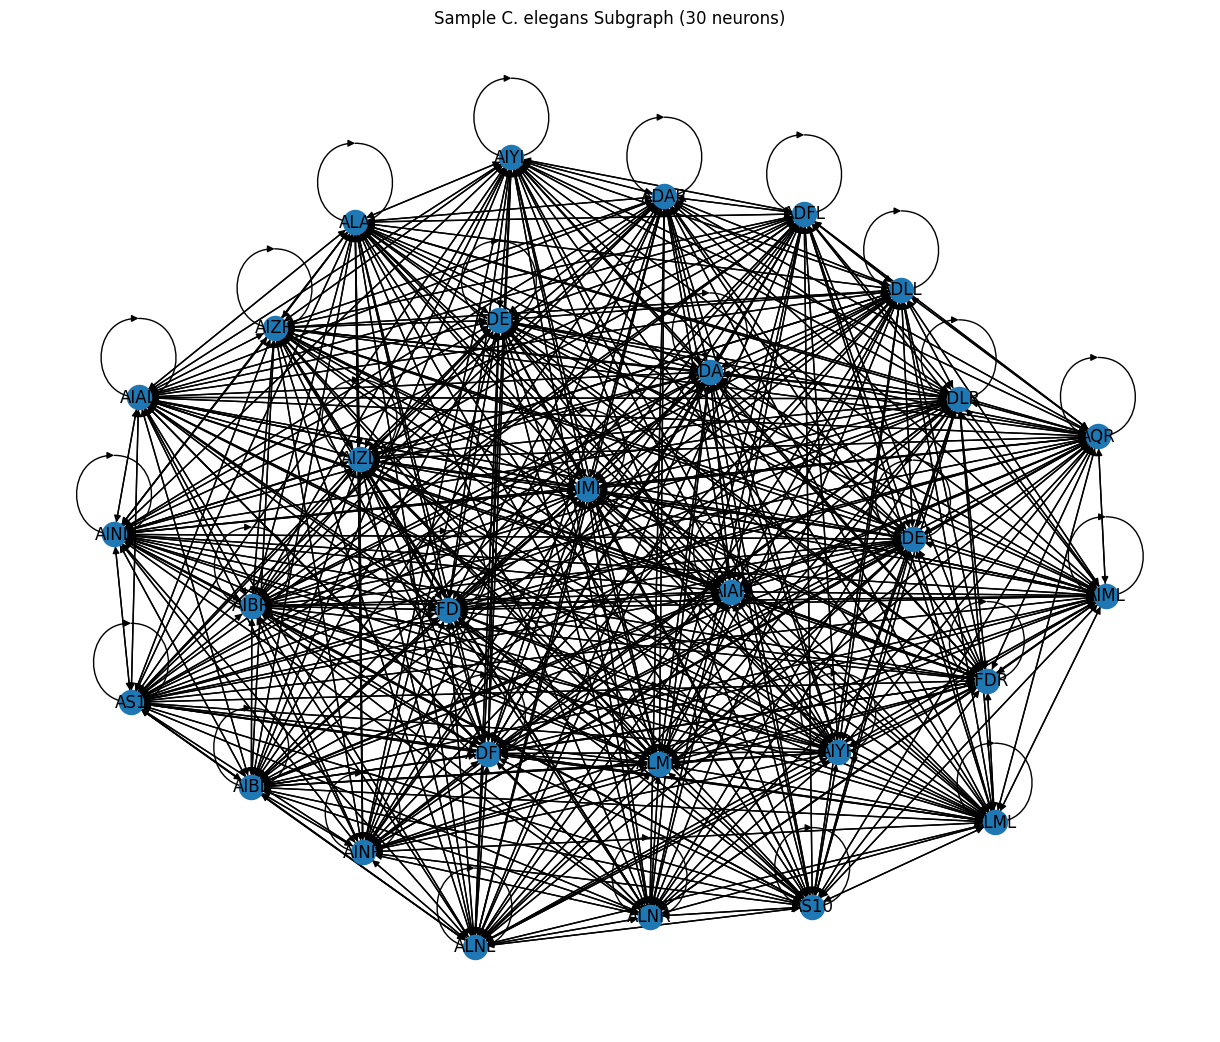

In [71]:
sub_nodes = list(G.nodes)[:30]
subG = G.subgraph(sub_nodes)

plt.figure(figsize=(12, 10))
nx.draw(subG, with_labels=True, node_size=300, arrows=True)
plt.title("Sample C. elegans Subgraph (30 neurons)")
plt.show()


In [72]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline


In [73]:
# Load connectome
connectome_df = pd.read_csv("celegans_connectome_data/consensus_connectome_full_withfunc.csv")

# Load neural metadata
neural_df = pd.read_parquet("celegans_neural_data/worm_data_short.parquet")

# Normalize column names
connectome_df.columns = connectome_df.columns.str.strip().str.lower()
neural_df.columns = neural_df.columns.str.strip().str.lower()

# Quick checks
display(connectome_df.head())
display(neural_df.head())


,from_neuron,to_neuron,from_pos,to_pos,from_type,to_type,mean_gap_weight,mean_chem_weight,uncertainty,functional_weight,data_sources
0,ADAL,ADAL,"(0.03, 94.34, 10.31)","(0.03, 94.34, 10.31)",inter,inter,NaN,6.0,NaN,NaN,['cook2019']
1,ADAL,ADAR,"(0.03, 94.34, 10.31)","(-1.43, 91.22, -11.64)",inter,inter,2.000000,NaN,NaN,0.091616,"['chklovskii', 'cook2019', 'funconn', 'openwor..."
2,ADAL,ADEL,"(0.03, 94.34, 10.31)","(-0.12, 87.97, 10.5)",inter,sensory,NaN,NaN,NaN,NaN,[]
3,ADAL,ADER,"(0.03, 94.34, 10.31)","(-0.58, 83.23, -11.47)",inter,sensory,NaN,NaN,NaN,0.014166,['funconn']
4,ADAL,ADFL,"(0.03, 94.34, 10.31)","(8.48, 54.18, 7.0)",inter,sensory,2.666667,NaN,NaN,NaN,"['chklovskii', 'cook2019', 'openworm', 'white1..."


,source_dataset,raw_data_file,worm,neuron,slot,is_labeled_neuron,smooth_method,interpolate_method,normalization_method,original_calcium_data,calcium_data,original_time_in_seconds,time_in_seconds,original_max_timesteps,max_timesteps
0,Kato2015,opensource_neural_data/Kato2015/WT_Stim.mat,worm0,AFDL,8,True,moving,linear,standard,"[0.25585938, 0.25634766, 0.2548828, 0.23376465...","[3.2714844, 3.2714844, 3.2070312, 3.1230469, 3...","[0.0, 0.32763672, 0.65527344, 0.98291016, 1.31...","[0.0, 0.3330078, 0.6660156, 0.99902344, 1.3320...",2198,2161
1,Kato2015,opensource_neural_data/Kato2015/WT_Stim.mat,worm0,AIBL,12,True,moving,linear,standard,"[1.6142578, 1.4101562, 1.2851562, 1.1816406, 1...","[4.2070312, 3.8652344, 3.6035156, 3.3828125, 3...","[0.0, 0.32763672, 0.65527344, 0.98291016, 1.31...","[0.0, 0.3330078, 0.6660156, 0.99902344, 1.3320...",2198,2161
2,Kato2015,opensource_neural_data/Kato2015/WT_Stim.mat,worm0,AIBR,13,True,moving,linear,standard,"[1.2714844, 1.2363281, 1.0966797, 1.0292969, 0...","[4.4921875, 4.3320312, 4.0976562, 3.8945312, 3...","[0.0, 0.32763672, 0.65527344, 0.98291016, 1.31...","[0.0, 0.3330078, 0.6660156, 0.99902344, 1.3320...",2198,2161
3,Kato2015,opensource_neural_data/Kato2015/WT_Stim.mat,worm0,ALA,22,True,moving,linear,standard,"[2.109375, 1.9091797, 1.8144531, 1.7177734, 1....","[9.6328125, 9.1796875, 8.8515625, 8.6015625, 8...","[0.0, 0.32763672, 0.65527344, 0.98291016, 1.31...","[0.0, 0.3330078, 0.6660156, 0.99902344, 1.3320...",2198,2161
4,Kato2015,opensource_neural_data/Kato2015/WT_Stim.mat,worm0,ASKL,49,True,moving,linear,standard,"[0.5756836, 0.6015625, 0.6738281, 0.6933594, 0...","[3.4492188, 3.6503906, 3.8984375, 4.0195312, 4...","[0.0, 0.32763672, 0.65527344, 0.98291016, 1.31...","[0.0, 0.3330078, 0.6660156, 0.99902344, 1.3320...",2198,2161


In [74]:
G = nx.DiGraph()

for _, row in connectome_df.iterrows():
    src = row['from_neuron']
    tgt = row['to_neuron']
    
    # Edge weights and metadata
    G.add_edge(
        src, tgt,
        gap_weight = row.get('mean_gap_weight', 0),
        chem_weight = row.get('mean_chem_weight', 0),
        functional_weight = row.get('functional_weight', 0),
        from_type = row.get('from_type'),
        to_type = row.get('to_type'),
        from_pos = row.get('from_pos'),
        to_pos = row.get('to_pos'),
        sources = row.get('data_sources', [])
    )


In [75]:
# Add neuron-level metadata
for _, row in neural_df.iterrows():
    neuron = row['neuron']
    if neuron in G.nodes:
        for key in row.index:
            G.nodes[neuron][key] = row[key]


In [76]:
print(f"Number of neurons: {G.number_of_nodes()}")
print(f"Number of synaptic connections: {G.number_of_edges()}")

# Degree
degree_vals = [d for n, d in G.degree()]
print(f"Mean degree: {np.mean(degree_vals):.2f}")
print(f"Max degree: {np.max(degree_vals)}")

# Top 10 hubs
hubs = sorted(G.degree, key=lambda x: x[1], reverse=True)[:10]
print("Top 10 most connected neurons:")
for neuron, degree in hubs:
    print(f"{neuron}: {degree}")


Number of neurons: 300
Number of synaptic connections: 90000
Mean degree: 600.00
Max degree: 600
Top 10 most connected neurons:
ADAL: 600
ADAR: 600
ADEL: 600
ADER: 600
ADFL: 600
ADFR: 600
ADLL: 600
ADLR: 600
AFDL: 600
AFDR: 600


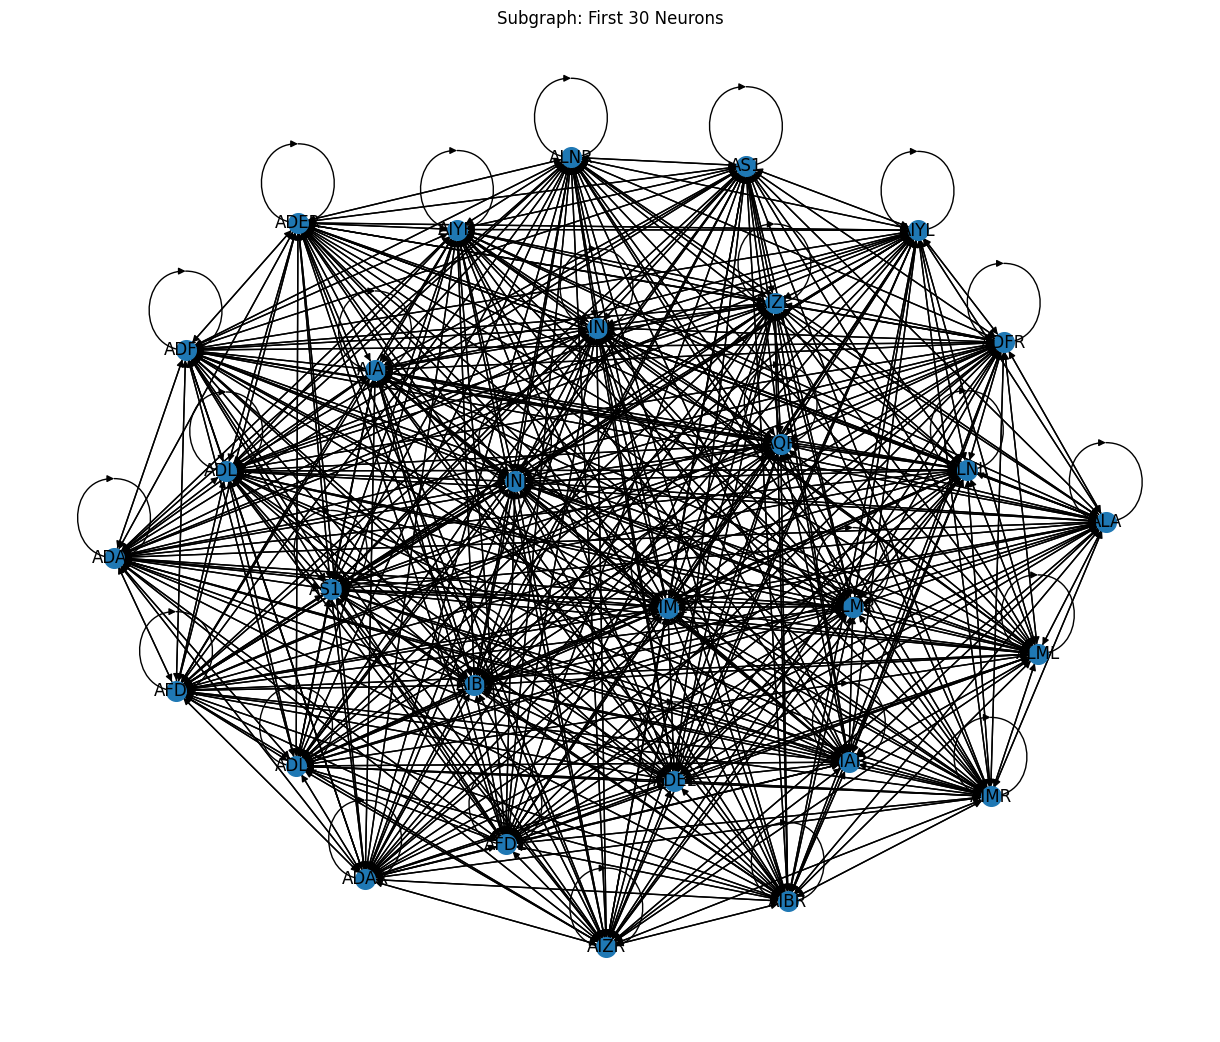

In [77]:
sub_nodes = list(G.nodes)[:30]
subG = G.subgraph(sub_nodes)

plt.figure(figsize=(12, 10))
nx.draw(subG, with_labels=True, node_size=200, arrows=True)
plt.title("Subgraph: First 30 Neurons")
plt.show()


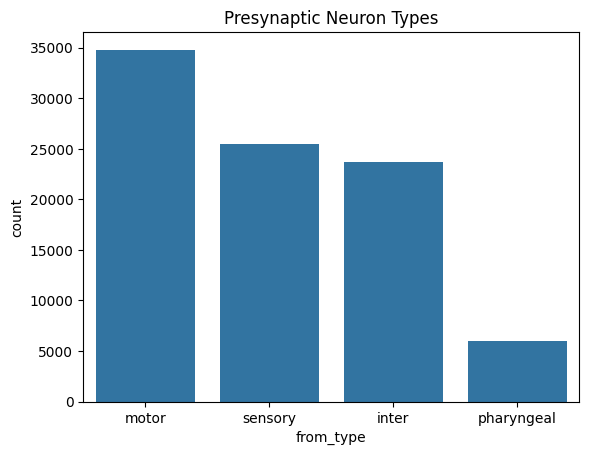

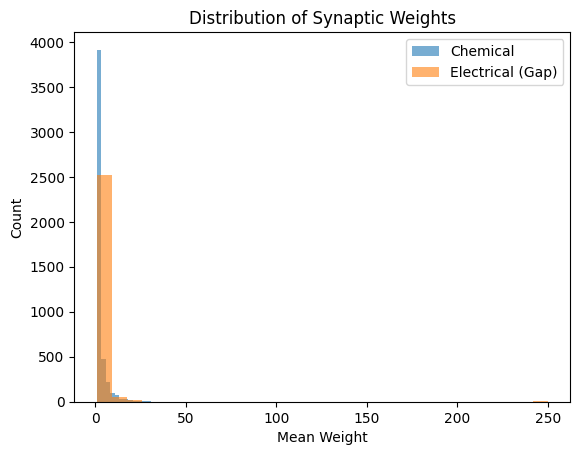

In [78]:
sns.countplot(data=connectome_df, x="from_type", order=connectome_df['from_type'].value_counts().index)
plt.title("Presynaptic Neuron Types")
plt.show()

# Edge type histogram
chem = connectome_df['mean_chem_weight'].dropna()
gap = connectome_df['mean_gap_weight'].dropna()

plt.hist(chem, bins=30, alpha=0.6, label='Chemical')
plt.hist(gap, bins=30, alpha=0.6, label='Electrical (Gap)')
plt.legend()
plt.title("Distribution of Synaptic Weights")
plt.xlabel("Mean Weight")
plt.ylabel("Count")
plt.show()


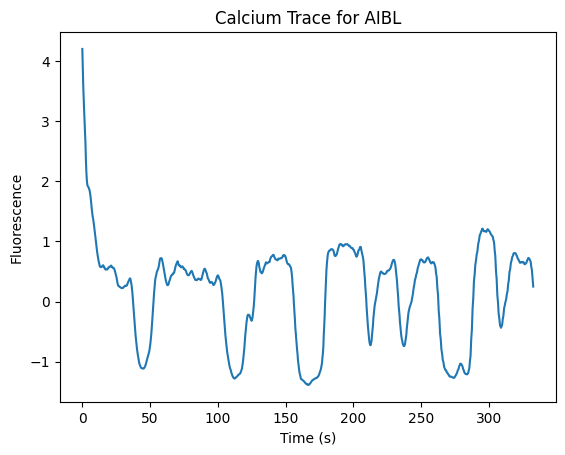

In [79]:
example_neuron = 'AIBL'

if example_neuron in neural_df['neuron'].values:
    neuron_row = neural_df[neural_df['neuron'] == example_neuron].iloc[0]
    trace = neuron_row['calcium_data']
    time = neuron_row['time_in_seconds']
    
    plt.plot(time[:1000], trace[:1000])
    plt.title(f"Calcium Trace for {example_neuron}")
    plt.xlabel("Time (s)")
    plt.ylabel("Fluorescence")
    plt.show()


In [1]:
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt
import seaborn as sns

# ---- STEP 1: LINEAGE DISTANCE ---- #
def compute_lineage_distance_matrix(lineage_dict):
    """
    lineage_dict: dict mapping neuron -> lineage string (e.g., 'AB.arappa')
    Returns symmetric lineage distance matrix based on LCA depth.
    """
    neurons = list(lineage_dict.keys())
    N = len(neurons)
    dist_matrix = np.zeros((N, N))

    def lca_depth(a, b):
        a_split = lineage_dict[a].split('.')
        b_split = lineage_dict[b].split('.')
        shared = 0
        for x, y in zip(a_split, b_split):
            if x == y:
                shared += 1
            else:
                break
        return len(a_split) + len(b_split) - 2 * shared  # simple tree distance

    for i in range(N):
        for j in range(i, N):
            d = lca_depth(neurons[i], neurons[j])
            dist_matrix[i, j] = dist_matrix[j, i] = d

    return neurons, dist_matrix

# ---- STEP 2: FUNCTIONAL SIMILARITY ---- #
def compute_functional_similarity_matrix(projection_vectors):
    """
    projection_vectors: dict mapping neuron -> 1D projection vector
    Returns cosine similarity matrix
    """
    neurons = list(projection_vectors.keys())
    matrix = np.array([projection_vectors[n] for n in neurons])
    sim_matrix = cosine_similarity(matrix)
    return neurons, sim_matrix

# ---- STEP 3: CORRELATION + VISUALIZATION ---- #
def plot_lineage_vs_function(neurons, lineage_dists, func_sims):
    """
    Scatter plot: lineage distance vs. functional similarity
    """
    assert neurons == neurons  # Ensure same order
    triu_indices = np.triu_indices(len(neurons), k=1)
    lin_d = lineage_dists[triu_indices]
    fun_s = func_sims[triu_indices]

    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=lin_d, y=fun_s, alpha=0.5)
    plt.title("Lineage Distance vs. Functional Similarity")
    plt.xlabel("Lineage Distance")
    plt.ylabel("Functional Similarity (cosine)")
    plt.grid(True)
    plt.show()

    corr = np.corrcoef(lin_d, fun_s)[0, 1]
    print(f"Pearson correlation: {corr:.3f}")

# ---- OPTIONAL: CLUSTERING HEATMAPS ---- #
def plot_clustermap(matrix, labels, title):
    sns.clustermap(matrix, xticklabels=labels, yticklabels=labels,
                   cmap='vlag', metric='euclidean')
    plt.title(title)
    plt.show()


/home/rohit/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "
